In [2]:
import folium
from folium import Marker
from folium import plugins
from folium import GeoJson
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [3]:
df=pd.read_csv("datasets/Starbucks_Seoul.csv")

geo="./datasets/Seoul_Gu.json"

df.head()

,name,address,gu_name,latitude,longitude
0,GS타워,서울특별시 강남구 논현로 508 (역삼동),강남구,37.501859,127.037278
1,SSG마켓도곡R,"서울특별시 강남구 언주로30길 57, 타워팰리스Ⅱ F 지하1층 (도곡동)",강남구,37.490298,127.054895
2,W-Mall,서울특별시 금천구 디지털로 188 (가산동),금천구,37.477305,126.887691
3,가든파이브,서울특별시 송파구 충민로 10 (문정동) 가든파이브툴,송파구,37.478232,127.119370
4,가락본동,서울특별시 송파구 송파대로30길 13 (가락동),송파구,37.494895,127.118785


In [11]:
m = folium.Map(location=[37.541, 126.986], zoom_start=12)
m

In [30]:
m = folium.Map(location=[37.541, 126.986], tiles='Stadia.StamenToner', zoom_start=12)

folium.CircleMarker([37.5538, 126.9810], radius=50,
                   popup='Laurelhurst Park', color='#3246cc',
                   fill_color='#3246cc').add_to(m)

folium.Marker([37.5538, 126.9810], popup='The Waterfront').add_to(m)
m

In [28]:
m = folium.Map([37.541, 126.986], zoom_start=12, width="100%", height="100%")
locations = list(zip(df.latitude, df.longitude))
cluster=plugins.MarkerCluster(locations=locations,
                              popups=df["name"].tolist())
m.add_child(cluster)
m

In [27]:
m = folium.Map(location=[37.54, 126.986], zoom_start=12, width="100%", height="100%")
locations = list(zip(df.latitude, df.longitude))
for i in range(len(locations)):
    folium.CircleMarker(location=locations[i], radius=1).add_to(m)
m

In [31]:
df_m=df.groupby('gu_name').agg({'latitude': 'mean',
                               'longitude': 'mean',
                               'name': 'count'}).reset_index()
df_m.head()

,gu_name,latitude,longitude,name
0,강남구,37.507603,127.044611,80
1,강동구,37.539914,127.137106,14
2,강북구,37.626866,127.026372,5
3,강서구,37.555716,126.841528,16
4,관악구,37.481759,126.944286,11


In [34]:
m = folium.Map(location=[37.541, 126.986], tiles='CartoDB.Positron',
               zoom_start=11, wiwdth="100%", height="100%")

folium.Choropleth(
    geo_data=geo,
    fill_color="gray"
).add_to(m)

locations = list(zip(df_m.latitude, df_m.longitude))
for i in range(len(locations)):
    row = df_m.iloc[i] # dataFrame에서 행 번호로 특정 행 선택하는 방법
    folium.CircleMarker(
        location=locations[i],
        radius=float(row.name/2),
        fill_color="blue"
    ).add_to(m)
m

In [38]:
df2 = pd.read_csv("datasets/us_states_unemployment.csv")
us_geo="datasets/folium_us-states.json"

df2.head()

,State,Unemployment
0,AL,7.1
1,AK,6.8
2,AZ,8.1
3,AR,7.2
4,CA,10.1


In [47]:
m = folium.Map(location=[40,-98], zoom_start=3, tiles='CartodbPositron')

folium.Choropleth(geo_data=us_geo,
             data=df2,
             columns=['State', 'Unemployment'], # json파일을 통해 특정 지역의 Unemployment를 확인 가능
             key_on='feature.id',
             fill_color='YlGn',
             legend_name='실업률').add_to(m)
m

In [48]:
source_to_dest = zip([37.541, 37.541, 37.541, 37.541, 37.541],
                     [35.6884, 38.9072, 14.5995, 48.8566, 55.7558],
                     [126.986, 126.986, 126.986, 126.986, 126.986],
                     [139.7690, -77.0369, 120.9842, 2.3522, 37.6173])
fig = go.Figure()

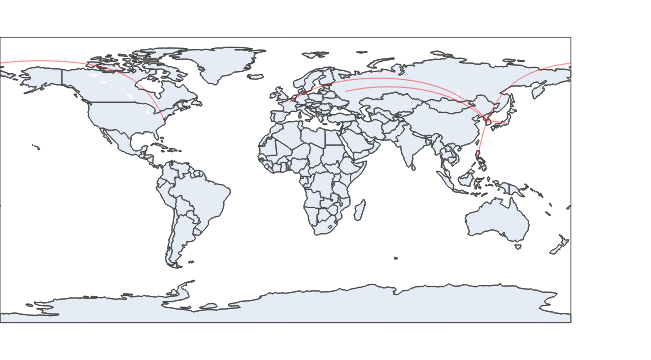

In [57]:
for a,b,c,d in source_to_dest:
    fig.add_trace(go.Scattergeo(
        lat=[a,b],
        lon=[c,d],
        mode='lines',
        line=dict(width=1,color="red"),
        opacity=0.5
    ))

fig.update_layout(
    margin={"t":0,"b":0,"l":0,"pad":0},
    showlegend=False,
    geo=dict(showcountries=True)
)
fig.show()